<a href="https://colab.research.google.com/github/dianakim0105/Time-dependent-reproduction-number-EVD-age-stratified-model-/blob/main/VE_Gaussian_mixture_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

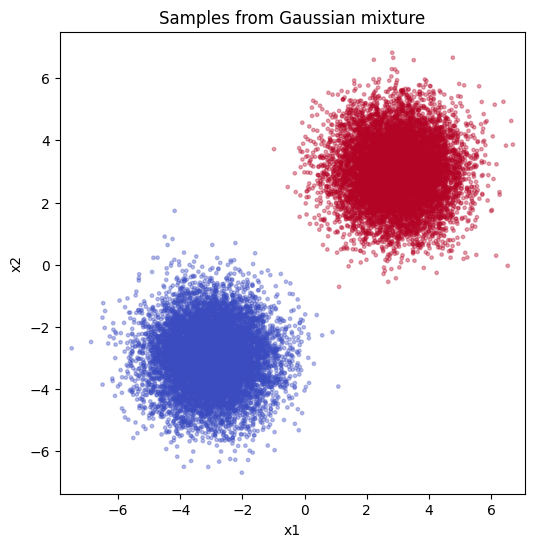

step   500 | loss 0.880832
step  1000 | loss 0.944828
step  1500 | loss 0.966091
step  2000 | loss 0.915566
step  2500 | loss 0.891584
step  3000 | loss 0.906475
step  3500 | loss 0.986436
step  4000 | loss 0.896470
step  4500 | loss 0.934786
step  5000 | loss 0.924863

Diagnostics vs TRUE noisy mixture score
   sigma        MSE        cosine
  1.0000    0.007271     0.9809
  0.5995    0.008252     0.9865
  0.3594    0.011862     0.9916
  0.2154    0.022008     0.9828
  0.1292    0.034722     0.9568
  0.0774    0.050152     0.9481
  0.0464    0.080622     0.9602
  0.0278    0.134044     0.9781
  0.0167    0.211400     0.9555
  0.0100    0.309636     0.8546


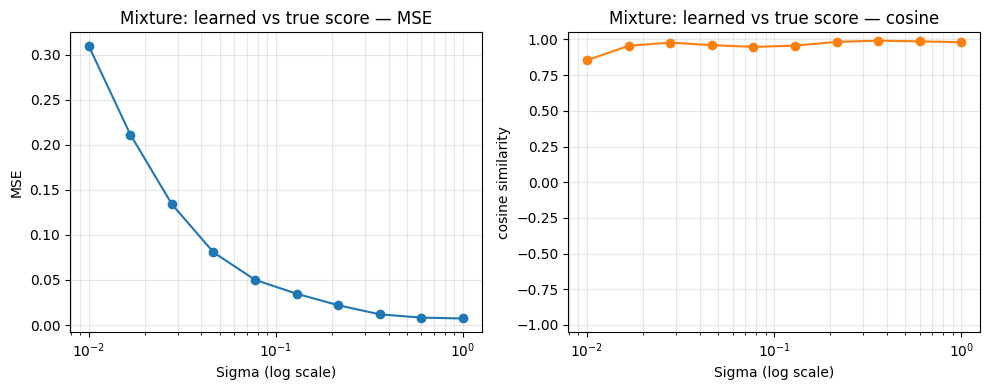

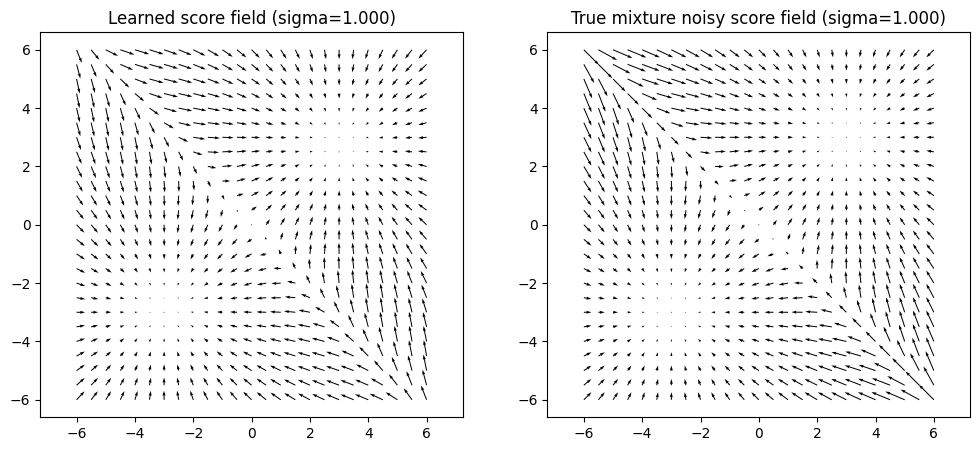

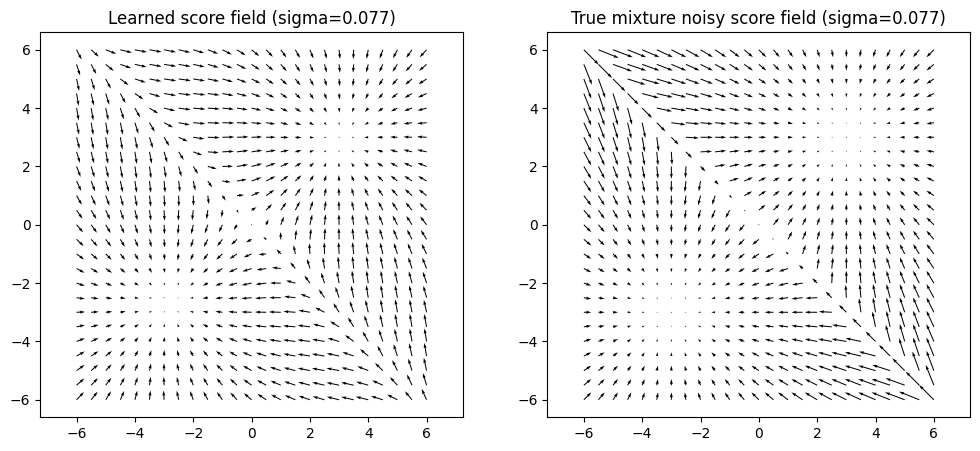

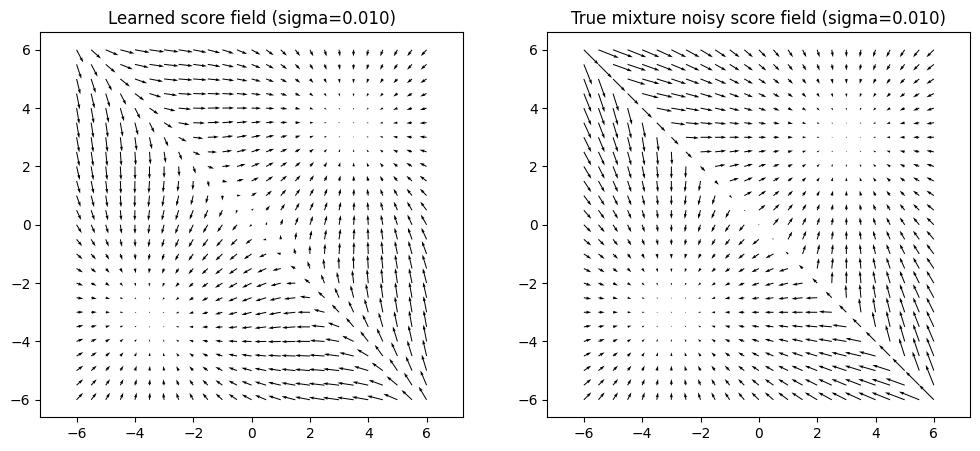

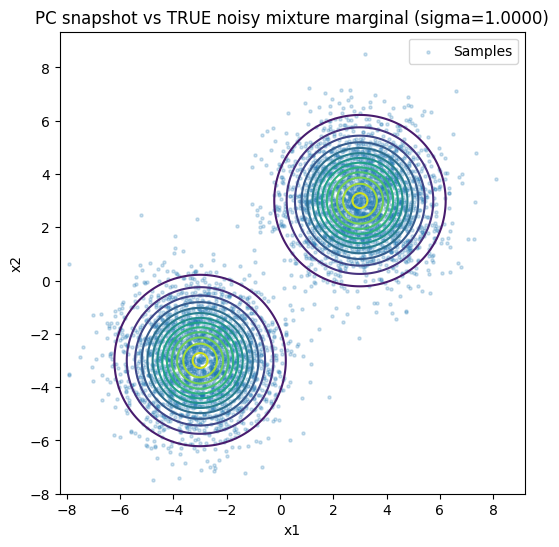

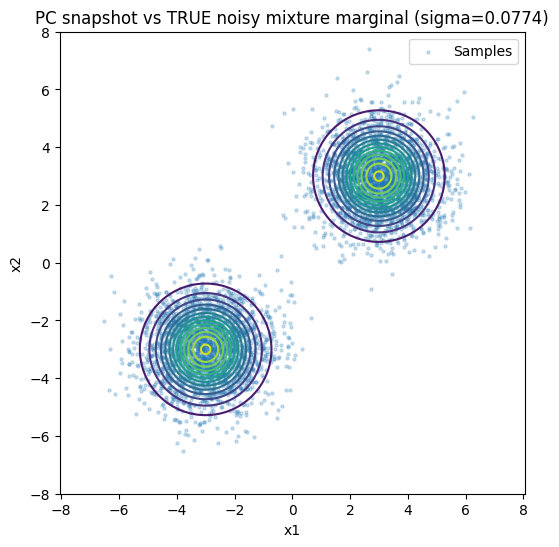

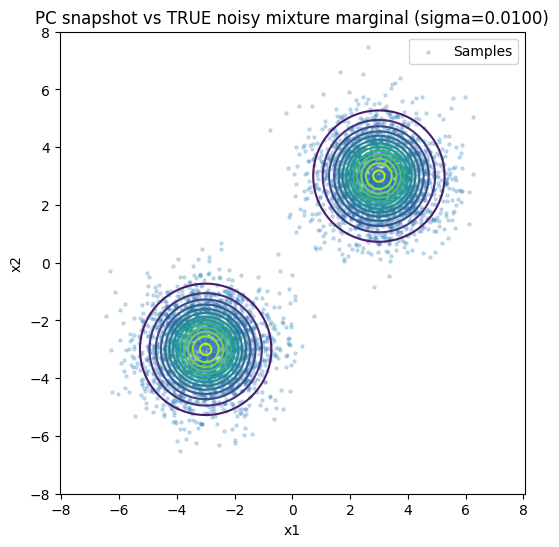

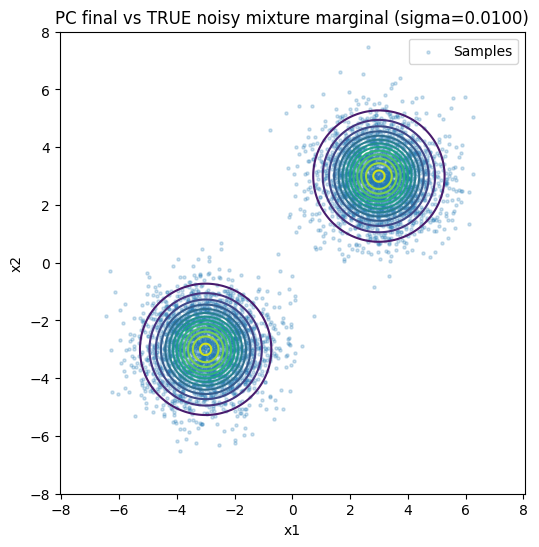


Global sampling diagnostics (samples vs TRUE noisy mixture marginal)
(sigma = 0.010000)
Generated mean: [0.0591979  0.03192479]
True mean:      [0. 0.]
Mean error:     [0.0591979  0.03192479]
Mean L2 error:  0.06725758933836017

Generated covariance:
 [[10.11313491  8.77567252]
 [ 8.77567252  9.67351317]]
True covariance (noisy marginal):
 [[10.0001  9.    ]
 [ 9.     10.0001]]
Covariance error:
 [[ 0.11303491 -0.22432748]
 [-0.22432748 -0.32658683]]
Covariance Frobenius error: 0.46912843648433494


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


# ============================================================
# 1) Data: 2D Gaussian mixture
# ============================================================
def sample_gaussian_mixture(n_samples, means, covs, weights, random_state=None):
    """
    Sample from a mixture of 2D Gaussians.

    Parameters
    ----------
    n_samples : int
        Number of samples to generate.
    means : list of np.ndarray
        Each mean has shape (2,)
    covs : list of np.ndarray
        Each covariance has shape (2,2)
    weights : np.ndarray or list
        Mixture weights, shape (K,)
    random_state : int or None
        Optional seed for reproducibility

    Returns
    -------
    samples : np.ndarray, shape (n_samples, 2)
    component_ids : np.ndarray, shape (n_samples,)
    """
    rng = np.random.default_rng(random_state)

    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / weights.sum()

    n_components = len(weights)
    assert len(means) == len(covs) == n_components, "Mismatch in number of components"

    component_ids = rng.choice(n_components, size=n_samples, p=weights)
    samples = np.zeros((n_samples, 2), dtype=np.float64)

    for k in range(n_components):
        idx = np.where(component_ids == k)[0]
        n_k = len(idx)
        if n_k > 0:
            samples[idx] = rng.multivariate_normal(
                mean=np.asarray(means[k], dtype=np.float64),
                cov=np.asarray(covs[k], dtype=np.float64),
                size=n_k,
            )

    return samples, component_ids


def sample_from_noisy_marginal_mixture(n_samples, means, covs, weights, sigma, device="cpu"):
    """
    Sample from the VE noisy marginal at noise level sigma:
        p_sigma(x) = sum_k w_k N(x | mu_k, Sigma_k + sigma^2 I).
    """
    weights_np = np.asarray(weights, dtype=np.float64)
    weights_np = weights_np / weights_np.sum()
    K = len(weights_np)
    w_t = torch.tensor(weights_np, dtype=torch.float32, device=device)
    idx = torch.multinomial(w_t, n_samples, replacement=True)
    x = torch.zeros(n_samples, 2, device=device, dtype=torch.float32)
    sig2 = float(sigma) ** 2

    for k in range(K):
        mask = idx == k
        n_k = int(mask.sum().item())
        if n_k == 0:
            continue
        mu_k = torch.tensor(means[k], dtype=torch.float32, device=device)
        Sigma_k = torch.tensor(covs[k], dtype=torch.float32, device=device)
        Sigma_s = Sigma_k + sig2 * torch.eye(2, device=device)
        L = torch.linalg.cholesky(Sigma_s)
        z = torch.randn(n_k, 2, device=device)
        x[mask] = mu_k + z @ L.T

    return x


# ============================================================
# 2) MLP score network s_theta(x_tilde, sigma)
#    input  = (x1, x2, log sigma)
#    output = (score1, score2)
# ============================================================
class ScoreNetMLP(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_tilde, sigma):
        log_sigma = torch.log(sigma).unsqueeze(1)  # (B,1)
        inp = torch.cat([x_tilde, log_sigma], dim=1)  # (B,3)
        return self.net(inp)  # (B,2)


# ============================================================
# 3) VE denoising score matching (DSM) training loop
#    corruption: x_tilde = x + sigma * eps
#    target:     -(x_tilde - x)/sigma^2 = -eps/sigma
# ============================================================
def train_dsm(
    model,
    dataloader,
    sigmas,
    steps=5000,
    lr=1e-3,
    device="cpu",
    sigma_weight=True,
):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sigmas = torch.tensor(sigmas, dtype=torch.float32, device=device)  # (K,)

    it = iter(dataloader)
    for step in range(1, steps + 1):
        try:
            x = next(it)[0].to(device)  # (B,2)
        except StopIteration:
            it = iter(dataloader)
            x = next(it)[0].to(device)

        B = x.shape[0]

        idx = torch.randint(0, sigmas.numel(), (B,), device=device)
        sigma = sigmas[idx]  # (B,)

        eps = torch.randn_like(x)
        x_tilde = x + sigma.unsqueeze(1) * eps

        target = -eps / sigma.unsqueeze(1)
        pred = model(x_tilde, sigma)

        if sigma_weight:
            w = (sigma**2).unsqueeze(1)
            loss = ((pred - target) ** 2 * w).mean()
        else:
            loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"step {step:5d} | loss {loss.item():.6f}")

    return model


# ============================================================
# 4) True noisy marginal for a Gaussian mixture under VE
# ============================================================
def true_noisy_score_mixture(x, means, covs, weights, sigma):
    """
    x:      torch tensor, shape (B,2)
    means:  list of arrays, each shape (2,)
    covs:   list of arrays, each shape (2,2)
    weights:list or array, shape (K,)
    sigma:  float

    returns:
        score: torch tensor, shape (B,2)
    """
    device = x.device
    B = x.shape[0]
    K = len(weights)

    weights_t = torch.tensor(weights, dtype=torch.float32, device=device)
    densities = []
    scores = []

    for k in range(K):
        mu_k = torch.tensor(means[k], dtype=torch.float32, device=device)
        Sigma_k = torch.tensor(covs[k], dtype=torch.float32, device=device)

        Sigma_sigma = Sigma_k + (sigma**2) * torch.eye(2, device=device)
        Sigma_inv = torch.linalg.inv(Sigma_sigma)

        diff = x - mu_k  # (B,2)

        exponent = -0.5 * torch.sum((diff @ Sigma_inv) * diff, dim=1)  # (B,)
        det = torch.det(Sigma_sigma)
        norm_const = 1.0 / torch.sqrt(((2 * torch.pi) ** 2) * det)
        density_k = norm_const * torch.exp(exponent)  # (B,)

        score_k = -(diff @ Sigma_inv.T)  # (B,2)

        densities.append(density_k)
        scores.append(score_k)

    densities = torch.stack(densities, dim=0)  # (K,B)
    scores = torch.stack(scores, dim=0)  # (K,B,2)

    weighted_densities = weights_t[:, None] * densities  # (K,B)
    denom = weighted_densities.sum(dim=0, keepdim=True)  # (1,B)
    gamma = weighted_densities / denom  # (K,B)

    score = torch.sum(gamma[:, :, None] * scores, dim=0)  # (B,2)
    return score


# ============================================================
# 5) Diagnostics: MSE + cosine similarity vs true noisy score
# ============================================================
@torch.no_grad()
def eval_mse_cosine_per_sigma_mixture(
    model,
    means,
    covs,
    weights,
    sigmas,
    device="cpu",
    n_test=5000,
):
    model.eval()

    mse_list = []
    cos_list = []
    sigma_list = []

    print("\nDiagnostics vs TRUE noisy mixture score")
    print("   sigma        MSE        cosine")

    for sigma in sigmas:
        sigma = float(sigma)

        samples_np, _ = sample_gaussian_mixture(
            n_samples=n_test,
            means=means,
            covs=covs,
            weights=weights,
            random_state=0,
        )
        x = torch.tensor(samples_np, dtype=torch.float32, device=device)

        eps = torch.randn_like(x)
        x_tilde = x + sigma * eps

        sigma_batch = torch.full((n_test,), sigma, dtype=torch.float32, device=device)

        pred = model(x_tilde, sigma_batch)
        true = true_noisy_score_mixture(x_tilde, means, covs, weights, sigma)

        mse = ((pred - true) ** 2).mean().item()
        cos = F.cosine_similarity(pred, true, dim=1).mean().item()

        sigma_list.append(sigma)
        mse_list.append(mse)
        cos_list.append(cos)

        print(f"{sigma:8.4f}  {mse:10.6f}   {cos:8.4f}")

    return sigma_list, mse_list, cos_list


def plot_mse_vs_sigma(sigmas, mses):
    plt.figure(figsize=(6, 4))
    plt.plot(sigmas, mses, marker="o")
    plt.xscale("log")
    plt.xlabel("Sigma (log scale)")
    plt.ylabel("MSE")
    plt.title("Mixture: MSE vs Noise Level (sigma)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


def plot_mse_cosine_vs_sigma(sigmas, mses, coses):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(sigmas, mses, marker="o")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Sigma (log scale)")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Mixture: learned vs true score — MSE")
    axes[0].grid(True, which="both", alpha=0.3)

    axes[1].plot(sigmas, coses, marker="o", color="C1")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Sigma (log scale)")
    axes[1].set_ylabel("cosine similarity")
    axes[1].set_title("Mixture: learned vs true score — cosine")
    axes[1].set_ylim(-1.05, 1.05)
    axes[1].grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 6) Score field plots: learned vs true noisy score field
# ============================================================
@torch.no_grad()
def plot_score_fields_mixture(
    model,
    means,
    covs,
    weights,
    sigma,
    device="cpu",
    grid_n=25,
    span=6.0,
):
    model.eval()
    sigma = float(sigma)

    x1 = torch.linspace(-span, span, grid_n, device=device)
    x2 = torch.linspace(-span, span, grid_n, device=device)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")
    grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)  # (G,2)

    sigma_batch = torch.full((grid.shape[0],), sigma, device=device)

    pred = model(grid, sigma_batch).cpu().numpy()
    true = true_noisy_score_mixture(grid, means, covs, weights, sigma).cpu().numpy()
    grid_np = grid.cpu().numpy()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.quiver(grid_np[:, 0], grid_np[:, 1], pred[:, 0], pred[:, 1])
    plt.title(f"Learned score field (sigma={sigma:.3f})")
    plt.axis("equal")

    plt.subplot(1, 2, 2)
    plt.quiver(grid_np[:, 0], grid_np[:, 1], true[:, 0], true[:, 1])
    plt.title(f"True mixture noisy score field (sigma={sigma:.3f})")
    plt.axis("equal")

    plt.show()


# ============================================================
# 7) Visualise the mixture dataset
# ============================================================
def plot_mixture_samples(samples_np, component_ids=None):
    plt.figure(figsize=(6, 6))

    if component_ids is None:
        plt.scatter(samples_np[:, 0], samples_np[:, 1], s=6, alpha=0.35)
    else:
        plt.scatter(
            samples_np[:, 0],
            samples_np[:, 1],
            c=component_ids,
            s=6,
            alpha=0.35,
            cmap="coolwarm",
        )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Samples from Gaussian mixture")
    plt.axis("equal")
    plt.show()


# ============================================================
# 8) VE sampling: Annealed Langevin dynamics
#    x <- x + eta * s_theta(x, sigma) + sqrt(2 eta) z
# ============================================================
@torch.no_grad()
def sample_annealed_langevin(
    model,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=0.001,
    device="cpu",
    extra_steps_at_end=0,
    denoise=False,
):
    model.eval()
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = float(sigmas_t.min().item())

    # Start from a broad Gaussian at the largest noise scale
    x = torch.randn(n_samples, 2, device=device) * sigmas_t.max()

    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())
        sigma_batch = torch.full((n_samples,), s_val, device=device)
        # NCSN-style annealed Langevin step size
        eta = step_scale * ((sigma / sigma_min) ** 2)

        steps_here = n_steps_each
        if np.isclose(s_val, sigma_min):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_batch) + (2 * eta) ** 0.5 * z

    # Optional final "denoise" (no injected noise) at sigma_min to reduce dispersion
    if denoise:
        sigma_batch = torch.full((n_samples,), sigma_min, device=device)
        eta = step_scale
        for _ in range(max(1, int(n_steps_each // 5))):
            x = x + eta * model(x, sigma_batch)

    return x


def gaussian_mixture_noisy_marginal_density_grid(means, covs, weights, sigma, x1, x2):
    """
    Density of the noisy mixture marginal at sigma:
        sum_k w_k N(x | mu_k, Sigma_k + sigma^2 I).
    """
    means = [np.asarray(m, dtype=np.float64) for m in means]
    covs = [np.asarray(c, dtype=np.float64) for c in covs]
    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / weights.sum()
    sig2 = float(sigma) ** 2

    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    X = np.stack([X1, X2], axis=-1)
    Z = np.zeros_like(X1, dtype=np.float64)

    for w, mu, Sigma in zip(weights, means, covs):
        Sigma_s = Sigma + sig2 * np.eye(2)
        inv = np.linalg.inv(Sigma_s)
        det = np.linalg.det(Sigma_s)
        D = X - mu
        quad = np.einsum("...i,ij,...j->...", D, inv, D)
        norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
        Z += w * norm * np.exp(-0.5 * quad)

    return X1, X2, Z


def gaussian_mixture_density_grid(means, covs, weights, x1, x2):
    """
    Compute mixture density on a 2D grid.
    Returns meshgrid arrays X1, X2 and density Z.
    """
    means = [np.asarray(m, dtype=np.float64) for m in means]
    covs = [np.asarray(c, dtype=np.float64) for c in covs]
    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / weights.sum()

    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    X = np.stack([X1, X2], axis=-1)  # (...,2)
    Z = np.zeros_like(X1, dtype=np.float64)

    for w, mu, Sigma in zip(weights, means, covs):
        inv = np.linalg.inv(Sigma)
        det = np.linalg.det(Sigma)
        D = X - mu
        quad = np.einsum("...i,ij,...j->...", D, inv, D)
        norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
        Z += w * norm * np.exp(-0.5 * quad)

    return X1, X2, Z


def plot_final_samples_vs_true_mixture_contours(
    samples_np,
    means,
    covs,
    weights,
    levels=14,
    span=8.0,
):
    x1 = np.linspace(-span, span, 240)
    x2 = np.linspace(-span, span, 240)
    X1, X2, Z = gaussian_mixture_density_grid(means, covs, weights, x1, x2)

    plt.figure(figsize=(6, 6))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=5, alpha=0.22, label="Langevin final samples")
    plt.contour(X1, X2, Z, levels=levels)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Final samples vs TRUE Gaussian-mixture contours")
    plt.axis("equal")
    plt.legend()
    plt.show()


def plot_samples_vs_true_noisy_mixture_marginal(
    samples_np,
    means,
    covs,
    weights,
    sigma,
    levels=14,
    span=8.0,
    title=None,
):
    x1 = np.linspace(-span, span, 240)
    x2 = np.linspace(-span, span, 240)
    X1, X2, Z = gaussian_mixture_noisy_marginal_density_grid(means, covs, weights, sigma, x1, x2)

    plt.figure(figsize=(6, 6))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=5, alpha=0.22, label="Samples")
    plt.contour(X1, X2, Z, levels=levels)
    plt.xlabel("x1")
    plt.ylabel("x2")
    if title is None:
        title = f"Samples vs TRUE noisy mixture marginal (sigma={sigma:.4f})"
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


@torch.no_grad()
def sample_pc_reverse_sde_mixture(
    model,
    sigmas,
    means,
    covs,
    weights,
    n_samples=5000,
    n_corrector_steps=2,
    corrector_step_scale=1e-5,
    device="cpu",
    denoise=False,
    snapshot_sigmas=None,
):
    """
    PC sampler for VE with learned score. Initialise from the true noisy mixture
    marginal at sigma_max (same family as the forward process).
    """
    model.eval()
    sigmas_sorted = np.array(sorted([float(s) for s in sigmas], reverse=True), dtype=np.float32)
    sigmas_t = torch.tensor(sigmas_sorted, dtype=torch.float32, device=device)
    sigma_min = sigmas_t[-1]

    snaps = {}
    snapshot_set = {float(s) for s in snapshot_sigmas} if snapshot_sigmas is not None else set()

    sigma_max = float(sigmas_t[0].item())
    x = sample_from_noisy_marginal_mixture(
        n_samples, means, covs, weights, sigma_max, device=device
    )

    s0 = sigma_max
    if s0 in snapshot_set and s0 not in snaps:
        snaps[s0] = x.detach().clone()

    for i in range(len(sigmas_t) - 1):
        sigma_i = float(sigmas_t[i].item())
        sigma_next = float(sigmas_t[i + 1].item())

        sigma_i_batch = torch.full((n_samples,), sigma_i, device=device)
        score_i = model(x, sigma_i_batch)
        delta_var = sigma_i**2 - sigma_next**2
        z = torch.randn_like(x)
        x = x + delta_var * score_i + (delta_var**0.5) * z

        sigma_next_batch = torch.full((n_samples,), sigma_next, device=device)
        eta = float(corrector_step_scale * ((sigma_next / float(sigma_min.item())) ** 2))
        for _ in range(n_corrector_steps):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_next_batch) + (2 * eta) ** 0.5 * z

        if sigma_next in snapshot_set and sigma_next not in snaps:
            snaps[sigma_next] = x.detach().clone()

    if denoise:
        sigma_last = float(sigma_min.item())
        sigma_last_batch = torch.full((n_samples,), sigma_last, device=device)
        x = x + (sigma_last**2) * model(x, sigma_last_batch)

    return x, snaps


def true_noisy_mixture_moments(means, covs, weights, sigma):
    """
    Analytic mean and covariance of sum_k w_k N(mu_k, Sigma_k + sigma^2 I).
    Mean equals the clean mixture mean; covariance adds isotropic noise to each component.
    """
    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / weights.sum()
    means = [np.asarray(m, dtype=np.float64) for m in means]
    covs = [np.asarray(c, dtype=np.float64) for c in covs]
    mean_bar = np.sum([w * m for w, m in zip(weights, means)], axis=0)
    sig2 = float(sigma) ** 2
    cov_bar = np.zeros((2, 2), dtype=np.float64)
    for w, m, c in zip(weights, means, covs):
        delta = (m - mean_bar).reshape(2, 1)
        cov_bar += w * (c + sig2 * np.eye(2) + delta @ delta.T)
    return mean_bar, cov_bar


def print_global_sample_diagnostics_noisy_marginal(samples_np, means, covs, weights, sigma):
    mean_true, cov_true = true_noisy_mixture_moments(means, covs, weights, sigma)
    mean_gen = samples_np.mean(axis=0)
    cov_gen = np.cov(samples_np.T)

    print("\nGlobal sampling diagnostics (samples vs TRUE noisy mixture marginal)")
    print(f"(sigma = {sigma:.6f})")
    print("Generated mean:", mean_gen)
    print("True mean:     ", mean_true)
    print("Mean error:    ", mean_gen - mean_true)
    print("Mean L2 error: ", np.linalg.norm(mean_gen - mean_true))

    print("\nGenerated covariance:\n", cov_gen)
    print("True covariance (noisy marginal):\n", cov_true)
    print("Covariance error:\n", cov_gen - cov_true)
    print("Covariance Frobenius error:", np.linalg.norm(cov_gen - cov_true, ord="fro"))


def true_mixture_moments(means, covs, weights):
    """
    Analytic mean/covariance of a Gaussian mixture.
    """
    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / weights.sum()
    means = [np.asarray(m, dtype=np.float64) for m in means]
    covs = [np.asarray(c, dtype=np.float64) for c in covs]

    mean_true = np.sum([w * m for w, m in zip(weights, means)], axis=0)
    cov_true = np.zeros((2, 2), dtype=np.float64)
    for w, m, c in zip(weights, means, covs):
        delta = (m - mean_true).reshape(2, 1)
        cov_true += w * (c + delta @ delta.T)
    return mean_true, cov_true


def print_global_sample_diagnostics(samples_np, means, covs, weights):
    """
    Compare generated global moments against analytic mixture moments.
    """
    mean_true, cov_true = true_mixture_moments(means, covs, weights)
    mean_gen = samples_np.mean(axis=0)
    cov_gen = np.cov(samples_np.T)

    mean_err = mean_gen - mean_true
    cov_err = cov_gen - cov_true

    print("\nGlobal sampling diagnostics (final samples vs TRUE mixture)")
    print("Generated mean:", mean_gen)
    print("True mean:     ", mean_true)
    print("Mean error:    ", mean_err)
    print("Mean L2 error: ", np.linalg.norm(mean_err))

    print("\nGenerated covariance:\n", cov_gen)
    print("True covariance:\n", cov_true)
    print("Covariance error:\n", cov_err)
    print("Covariance Frobenius error:", np.linalg.norm(cov_err, ord="fro"))


# ============================================================
# 9) Run experiment
# ============================================================
def run_experiment():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(0)
    np.random.seed(0)

    means = [
        np.array([-3.0, -3.0]),
        np.array([3.0, 3.0]),
    ]

    covs = [
        np.eye(2),
        np.eye(2),
    ]

    weights = np.array([0.5, 0.5], dtype=np.float64)

    N = 20000
    samples_np, component_ids = sample_gaussian_mixture(
        n_samples=N,
        means=means,
        covs=covs,
        weights=weights,
        random_state=0,
    )

    plot_mixture_samples(samples_np, component_ids)

    x = torch.tensor(samples_np, dtype=torch.float32)
    loader = DataLoader(TensorDataset(x), batch_size=512, shuffle=True, drop_last=True)

    sigmas = np.geomspace(1.0, 0.01, 10).astype(np.float32)
    sigma_final = float(sigmas[-1])

    model = ScoreNetMLP(hidden_dim=128).to(device)

    train_dsm(
        model,
        loader,
        sigmas,
        steps=5000,
        lr=1e-3,
        device=device,
        sigma_weight=True,
    )

    sigma_list, mse_list, cos_list = eval_mse_cosine_per_sigma_mixture(
        model,
        means,
        covs,
        weights,
        sigmas,
        device=device,
        n_test=5000,
    )

    plot_mse_cosine_vs_sigma(sigma_list, mse_list, cos_list)

    for s in [sigmas[0], sigmas[len(sigmas) // 2], sigmas[-1]]:
        plot_score_fields_mixture(
            model,
            means,
            covs,
            weights,
            sigma=s,
            device=device,
            grid_n=25,
            span=6.0,
        )

    snapshot_sigmas = [float(sigmas[0]), float(sigmas[len(sigmas) // 2]), float(sigmas[-1])]

    final_x, snaps = sample_pc_reverse_sde_mixture(
        model,
        sigmas,
        means,
        covs,
        weights,
        n_samples=5000,
        n_corrector_steps=2,
        corrector_step_scale=1e-5,
        device=device,
        denoise=True,
        snapshot_sigmas=snapshot_sigmas,
    )

    for s in snapshot_sigmas:
        if s not in snaps:
            continue
        x_s = snaps[s].cpu().numpy()
        plot_samples_vs_true_noisy_mixture_marginal(
            x_s,
            means,
            covs,
            weights,
            sigma=s,
            levels=14,
            span=8.0,
            title=f"PC snapshot vs TRUE noisy mixture marginal (sigma={s:.4f})",
        )

    final_np = final_x.cpu().numpy()
    plot_samples_vs_true_noisy_mixture_marginal(
        final_np,
        means,
        covs,
        weights,
        sigma=sigma_final,
        levels=14,
        span=8.0,
        title=f"PC final vs TRUE noisy mixture marginal (sigma={sigma_final:.4f})",
    )
    print_global_sample_diagnostics_noisy_marginal(
        final_np, means, covs, weights, sigma=sigma_final
    )

    return model, sigmas, means, covs, weights


if __name__ == "__main__":
    run_experiment()

